# L12 — Relaxation & Contrast (runnable notebook)

**Module 3 · Day 18 · MRI1 Lecture 12 (F. Laun, FAU) + Exercise Sheet 12**

This notebook *builds* every concept from Lecture 12 on synthetic data:

1. The Bloch equations **with relaxation** — numerically integrated (the inward spiral)
2. $T_1$ recovery and $T_2$ decay curves (reproducing the lecture figures)
3. Inversion recovery and the null time $\mathrm{TI}=\ln2\,T_1$
4. $T_2$-weighting (long TE) and $T_1$-weighting (short TR)
5. The **steady state** of repeated excitations
6. The $T_1$w / $T_2$w / $\rho$w **contrast matrix** on a synthetic brain phantom
7. **FLAIR** and **STIR** suppression on the same phantom
8. $T_1$ and $T_2$ **mapping** by curve fitting
9. **Exercises 12.1, 12.2, 12.4** worked out in code

> Run it top to bottom. Then break things: change the field strength, the tissue times, TR/TE/TI, the noise level — that is where the learning happens.

In [1]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})

# Representative relaxation times at 1.5 T (lecture-rounded values, in ms).
# rho = relative proton density (rough, for the phantom demos).
TISSUES = {
    "CSF":          dict(T1=4500, T2=2200, rho=1.00, color="tab:blue"),
    "Gray matter":  dict(T1=1100, T2=95,   rho=0.85, color="tab:gray"),
    "White matter": dict(T1=900,  T2=70,   rho=0.70, color="black"),
    "Fat":          dict(T1=340,  T2=60,   rho=1.00, color="tab:orange"),
    "Liver":        dict(T1=600,  T2=45,   rho=0.90, color="tab:green"),
}
for name, p in TISSUES.items():
    print(f"{name:13s}  T1={p['T1']:>4} ms   T2={p['T2']:>4} ms   rho={p['rho']:.2f}")

CSF            T1=4500 ms   T2=2200 ms   rho=1.00
Gray matter    T1=1100 ms   T2=  95 ms   rho=0.85
White matter   T1= 900 ms   T2=  70 ms   rho=0.70
Fat            T1= 340 ms   T2=  60 ms   rho=1.00
Liver          T1= 600 ms   T2=  45 ms   rho=0.90


## 1. Bloch equations with relaxation — the inward spiral

We integrate the full Bloch equation in the rotating-frame-free lab picture

$$\dot M_x=-\omega M_y-\tfrac{M_x}{T_2},\quad
\dot M_y=\;\;\omega M_x-\tfrac{M_y}{T_2},\quad
\dot M_z=\tfrac{1}{T_1}(M_0-M_z)$$

Start just after a **90° pulse** ($M$ lying in the transverse plane). As in the lecture, we **rescale the precession frequency** so the spiral is actually visible — the real Larmor frequency (~64 MHz at 1.5 T) would draw far too many turns to see.

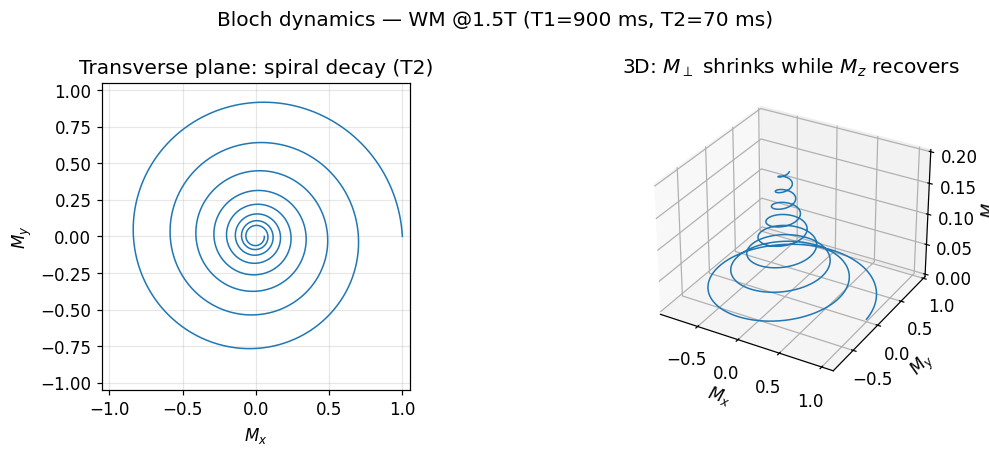

Check: |M_perp| should follow exp(-t/T2).
  |M_perp| at t=T2 (70 ms): 0.368  (expected 0.368 )


In [2]:
def bloch_rhs(t, M, w, T1, T2, M0=1.0):
    Mx, My, Mz = M
    return [-w*My - Mx/T2,
             w*Mx - My/T2,
             (M0 - Mz)/T1]

def simulate_fid(T1, T2, t_max, n_rot=8, M0=1.0, n=4000):
    '''Free precession + relaxation after a 90 deg pulse (M starts in xy-plane).'''
    w = 2*np.pi*n_rot / t_max          # rescaled precession rate -> n_rot visible turns
    t = np.linspace(0, t_max, n)
    sol = solve_ivp(bloch_rhs, (0, t_max), [M0, 0.0, 0.0],
                    args=(w, T1, T2, M0), t_eval=t, rtol=1e-8, atol=1e-10)
    return t, sol.y   # y = [Mx, My, Mz]

# White matter @ 1.5 T, watched for 200 ms (~ a few T2)
T1, T2 = TISSUES["White matter"]["T1"], TISSUES["White matter"]["T2"]
t, (Mx, My, Mz) = simulate_fid(T1, T2, t_max=200.0, n_rot=8)

fig = plt.figure(figsize=(11, 4.2))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(Mx, My, lw=1)
ax1.set_xlabel("$M_x$"); ax1.set_ylabel("$M_y$")
ax1.set_title("Transverse plane: spiral decay (T2)")
ax1.set_aspect("equal"); ax1.set_xlim(-1.05, 1.05); ax1.set_ylim(-1.05, 1.05)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(Mx, My, Mz, lw=1)
ax2.set_xlabel("$M_x$"); ax2.set_ylabel("$M_y$"); ax2.set_zlabel("$M_z$")
ax2.set_title("3D: $M_\\perp$ shrinks while $M_z$ recovers")
plt.suptitle(f"Bloch dynamics — WM @1.5T (T1={T1} ms, T2={T2} ms)")
plt.tight_layout(); plt.show()

print("Check: |M_perp| should follow exp(-t/T2).")
print(f"  |M_perp| at t=T2 ({T2} ms):", round(np.hypot(Mx, My)[np.argmin(abs(t-T2))], 3),
      " (expected", round(np.exp(-1), 3), ")")

## 2. $T_1$ longitudinal recovery

$$M_\parallel(t)=\big(M_\parallel(0)-M_0\big)e^{-t/T_1}+M_0$$

Reproducing the lecture figure with the representative times **fluid 4500 ms, liver 800 ms, fat 380 ms** (saturation recovery, $M_\parallel(0)=0$).

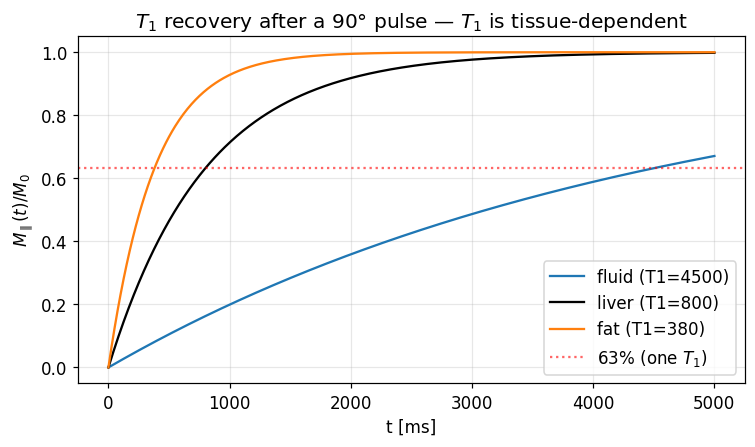

In [3]:
def Mpar_saturation(t, T1, M0=1.0):
    return M0*(1 - np.exp(-t/T1))

t = np.linspace(0, 5000, 600)
demo_T1 = {"fluid (T1=4500)": 4500, "liver (T1=800)": 800, "fat (T1=380)": 380}
colors  = {"fluid (T1=4500)": "tab:blue", "liver (T1=800)": "black", "fat (T1=380)": "tab:orange"}

plt.figure(figsize=(7, 4.2))
for label, T1 in demo_T1.items():
    plt.plot(t, Mpar_saturation(t, T1), color=colors[label], label=label)
plt.axhline(1-np.exp(-1), ls=":", color="r", alpha=.6, label="63% (one $T_1$)")
plt.xlabel("t [ms]"); plt.ylabel(r"$M_\parallel(t)/M_0$")
plt.title("$T_1$ recovery after a 90° pulse — $T_1$ is tissue-dependent")
plt.legend(); plt.tight_layout(); plt.show()

## 3. $T_2$ transverse decay

$$M_\perp(t)=M_\perp(0)\,e^{-t/T_2}$$

Representative times **fluid 2200 ms, liver 35 ms, fat 70 ms**. Note the *much* shorter horizontal axis than the $T_1$ plot — **$T_2\ll T_1$**.

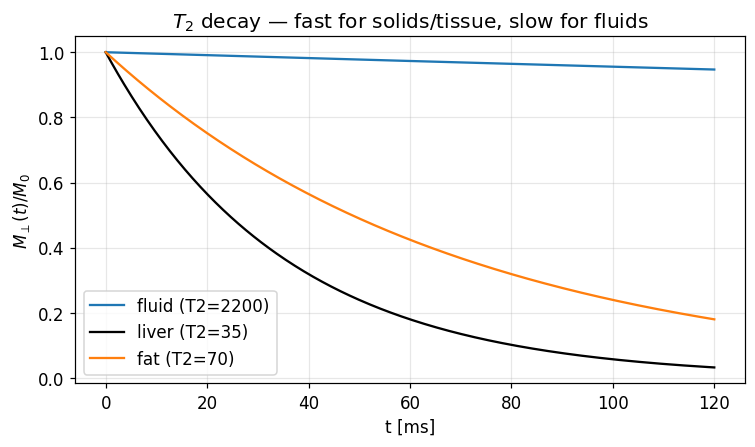

In [4]:
def Mperp_decay(t, T2, M0=1.0):
    return M0*np.exp(-t/T2)

t = np.linspace(0, 120, 400)
demo_T2 = {"fluid (T2=2200)": 2200, "liver (T2=35)": 35, "fat (T2=70)": 70}
colors  = {"fluid (T2=2200)": "tab:blue", "liver (T2=35)": "black", "fat (T2=70)": "tab:orange"}

plt.figure(figsize=(7, 4.2))
for label, T2 in demo_T2.items():
    plt.plot(t, Mperp_decay(t, T2), color=colors[label], label=label)
plt.xlabel("t [ms]"); plt.ylabel(r"$M_\perp(t)/M_0$")
plt.title("$T_2$ decay — fast for solids/tissue, slow for fluids")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Inversion recovery and the null time

After a **180°** pulse, $M_\parallel(0)=-M_0$:

$$M_\parallel(t)=M_0\big(1-2e^{-t/T_1}\big)$$

The curve crosses zero at $\mathrm{TI}=\ln2\,T_1$. Choosing TI there **nulls** that tissue — the basis of FLAIR and STIR.

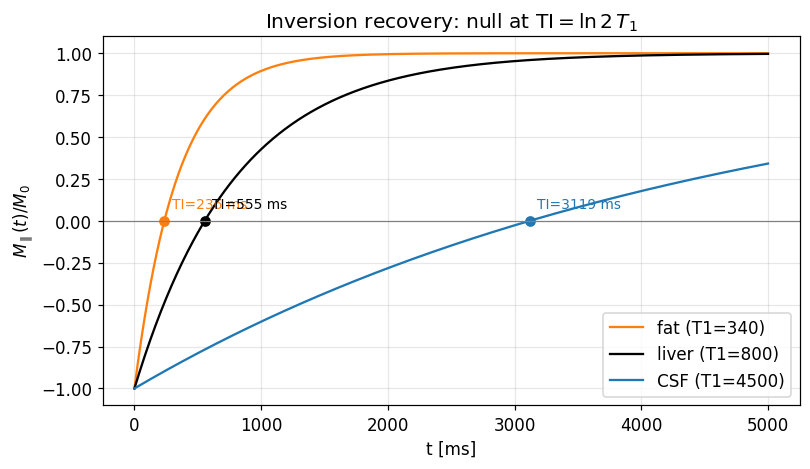

In [5]:
def Mpar_inversion(t, T1, M0=1.0):
    return M0*(1 - 2*np.exp(-t/T1))

t = np.linspace(0, 5000, 600)
plt.figure(figsize=(7.5, 4.4))
for label, T1, c in [("fat (T1=340)", 340, "tab:orange"),
                     ("liver (T1=800)", 800, "black"),
                     ("CSF (T1=4500)", 4500, "tab:blue")]:
    plt.plot(t, Mpar_inversion(t, T1), color=c, label=label)
    TI = np.log(2)*T1
    plt.plot(TI, 0, "o", color=c)
    plt.annotate(f"TI={TI:.0f} ms", (TI, 0), textcoords="offset points",
                 xytext=(5, 8), color=c, fontsize=9)
plt.axhline(0, color="gray", lw=.8)
plt.xlabel("t [ms]"); plt.ylabel(r"$M_\parallel(t)/M_0$")
plt.title(r"Inversion recovery: null at $\mathrm{TI}=\ln 2\,T_1$")
plt.legend(); plt.tight_layout(); plt.show()

## 5. $T_2$-weighting — *be patient*

Signal $\propto e^{-\mathrm{TE}/T_2}$. Short TE → everything isointense; long TE → long-$T_2$ tissues (CSF) stay bright.

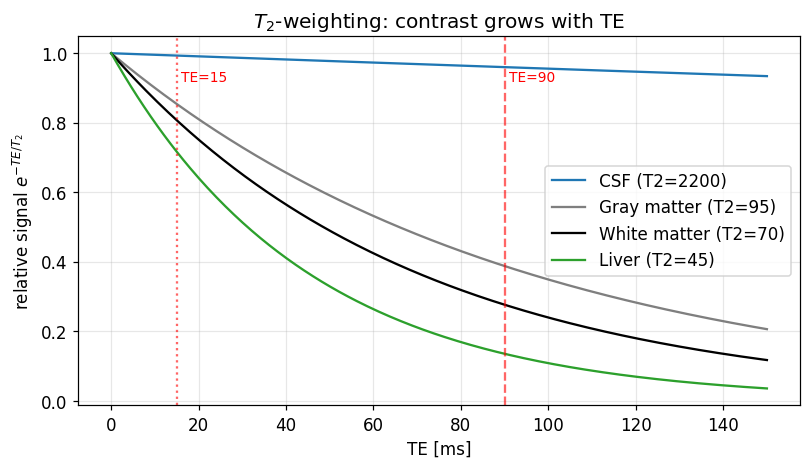

At short TE=15 ms vs long TE=90 ms, the CSF-vs-WM signal gap:
  TE=15 ms : CSF-WM = 0.186
  TE=90 ms : CSF-WM = 0.683


In [6]:
TE = np.linspace(0, 150, 300)
plt.figure(figsize=(7.5, 4.4))
for name in ["CSF", "Gray matter", "White matter", "Liver"]:
    p = TISSUES[name]
    plt.plot(TE, np.exp(-TE/p["T2"]), color=p["color"], label=f"{name} (T2={p['T2']})")
for te, style in [(15, ":"), (90, "--")]:
    plt.axvline(te, color="red", ls=style, alpha=.6)
    plt.text(te+1, 0.92, f"TE={te}", color="red", fontsize=9)
plt.xlabel("TE [ms]"); plt.ylabel(r"relative signal $e^{-TE/T_2}$")
plt.title("$T_2$-weighting: contrast grows with TE")
plt.legend(); plt.tight_layout(); plt.show()

print("At short TE=15 ms vs long TE=90 ms, the CSF-vs-WM signal gap:")
for te in (15, 90):
    gap = np.exp(-te/TISSUES['CSF']['T2']) - np.exp(-te/TISSUES['White matter']['T2'])
    print(f"  TE={te:>2} ms : CSF-WM = {gap:.3f}")

## 6. $T_1$-weighting — *be impatient*

Saturation-recovery signal $\propto 1-e^{-\mathrm{TR}/T_1}$. Short TR → short-$T_1$ tissues (fat) bright, long-$T_1$ (CSF) dark. Very long TR → all saturated → no $T_1$ contrast (proton-density-like).

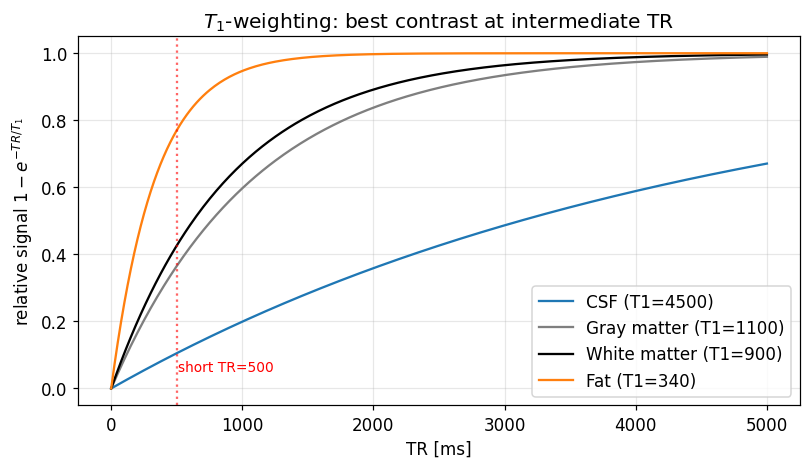

Fat-vs-CSF signal gap (T1 contrast) at different TR:
  TR= 500 ms : Fat-CSF = 0.665
  TR=2000 ms : Fat-CSF = 0.638
  TR=5000 ms : Fat-CSF = 0.329


In [7]:
TR = np.linspace(0, 5000, 400)
plt.figure(figsize=(7.5, 4.4))
for name in ["CSF", "Gray matter", "White matter", "Fat"]:
    p = TISSUES[name]
    plt.plot(TR, 1 - np.exp(-TR/p["T1"]), color=p["color"], label=f"{name} (T1={p['T1']})")
plt.axvline(500, color="red", ls=":", alpha=.6); plt.text(510, 0.05, "short TR=500", color="red", fontsize=9)
plt.xlabel("TR [ms]"); plt.ylabel(r"relative signal $1-e^{-TR/T_1}$")
plt.title("$T_1$-weighting: best contrast at intermediate TR")
plt.legend(); plt.tight_layout(); plt.show()

print("Fat-vs-CSF signal gap (T1 contrast) at different TR:")
for tr in (500, 2000, 5000):
    gap = ((1-np.exp(-tr/TISSUES['Fat']['T1'])) - (1-np.exp(-tr/TISSUES['CSF']['T1'])))
    print(f"  TR={tr:>4} ms : Fat-CSF = {gap:.3f}")

## 7. Steady state of repeated 90° pulses

A train of equally spaced 90° pulses (spacing TR) resets $M_z\to0$ each time, so after the first pulse every tissue rebuilds to the **same plateau** $M_0(1-e^{-\mathrm{TR}/T_1})$ before each readout. That is what "steady state" means: every k-space line of a given tissue carries identical $T_1$-weighting.

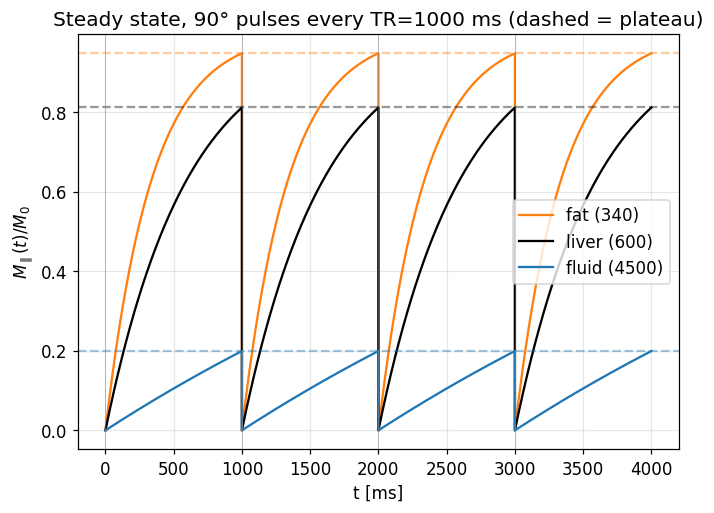

In [8]:
TR = 1000.0          # ms
n_pulses = 4
tt, mm = {}, {}
for label, T1, c in [("fat (340)", 340, "tab:orange"),
                     ("liver (600)", 600, "black"),
                     ("fluid (4500)", 4500, "tab:blue")]:
    times, Mz = [], []
    for k in range(n_pulses):
        seg = np.linspace(0, TR, 200)
        times.append(k*TR + seg)
        Mz.append(1 - np.exp(-seg/T1))     # recovers from 0 after each 90 deg pulse
    tt[label], mm[label], = np.concatenate(times), np.concatenate(Mz)
    plt.plot(tt[label], mm[label], color=c, label=label)
    plt.axhline(1-np.exp(-TR/T1), color=c, ls="--", alpha=.4)

for k in range(n_pulses):
    plt.axvline(k*TR, color="gray", lw=.6, alpha=.5)
plt.xlabel("t [ms]"); plt.ylabel(r"$M_\parallel(t)/M_0$")
plt.title(f"Steady state, 90° pulses every TR={TR:.0f} ms (dashed = plateau)")
plt.legend(); plt.tight_layout(); plt.show()

## 8. The $T_1$w / $T_2$w / $\rho$w contrast matrix

Spin-echo signal model:

$$S \propto \rho\,\big(1-e^{-\mathrm{TR}/T_1}\big)\,e^{-\mathrm{TE}/T_2}$$

We build a tiny synthetic "brain" (scalp fat, white matter, gray-matter rim, CSF ventricles) and render it under three $(\mathrm{TR},\mathrm{TE})$ presets.

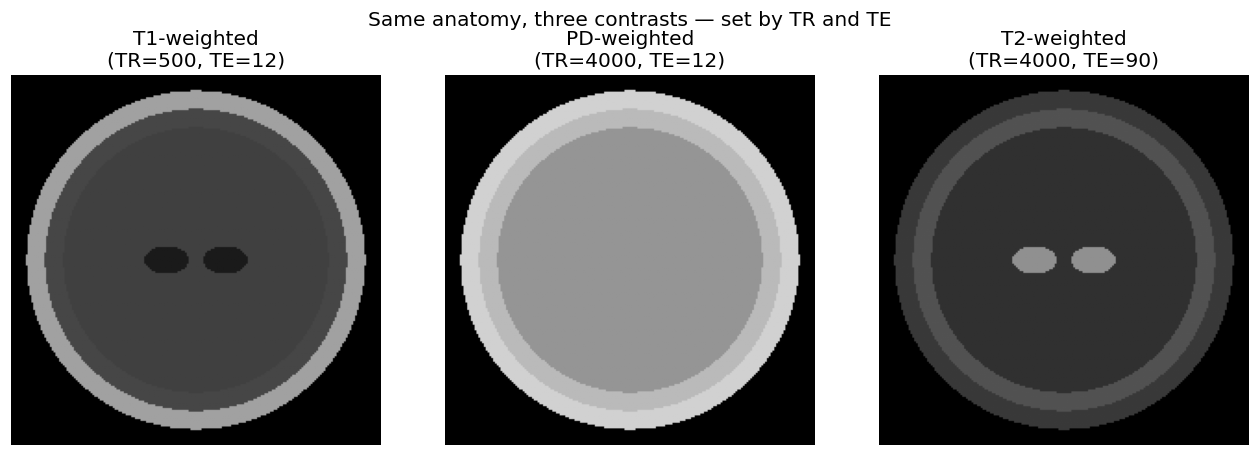

Notice: CSF is dark in T1w, bright in T2w. Fat is bright in T1w.


In [9]:
def make_phantom(N=200):
    '''Return a label map: 0 air, 1 fat, 2 white, 3 gray, 4 CSF.'''
    y, x = np.mgrid[-1:1:N*1j, -1:1:N*1j]
    r = np.hypot(x, y)
    lab = np.zeros((N, N), int)
    head = r < 0.92
    lab[head] = 1                       # scalp/fat shell
    lab[r < 0.82] = 3                   # gray-matter rim
    lab[r < 0.72] = 2                   # white matter
    # two ventricle blobs (CSF)
    for cx in (-0.16, 0.16):
        lab[np.hypot(x-cx, y*1.6) < 0.12] = 4
    return lab

LAB2TISSUE = {1: "Fat", 2: "White matter", 3: "Gray matter", 4: "CSF"}

def se_signal(lab, TR, TE):
    img = np.zeros(lab.shape, float)
    for code_, name in LAB2TISSUE.items():
        p = TISSUES[name]
        s = p["rho"]*(1-np.exp(-TR/p["T1"]))*np.exp(-TE/p["T2"])
        img[lab == code_] = s
    return img

lab = make_phantom()
presets = [("T1-weighted\n(TR=500, TE=12)", 500, 12),
           ("PD-weighted\n(TR=4000, TE=12)", 4000, 12),
           ("T2-weighted\n(TR=4000, TE=90)", 4000, 90)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, (title, TR, TE) in zip(axes, presets):
    ax.imshow(se_signal(lab, TR, TE), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title); ax.axis("off")
plt.suptitle("Same anatomy, three contrasts — set by TR and TE")
plt.tight_layout(); plt.show()

print("Notice: CSF is dark in T1w, bright in T2w. Fat is bright in T1w.")

## 9. FLAIR and STIR — nulling one tissue

Inversion-recovery readout (assume $\mathrm{TR}\gg T_1$ so full inversion each time):

$$S \propto \rho\,\big|1-2e^{-\mathrm{TI}/T_1}\big|\,e^{-\mathrm{TE}/T_2}$$

- **FLAIR:** $\mathrm{TI}=\ln2\cdot T_{1,\mathrm{CSF}}\approx3119$ ms → CSF nulled.
- **STIR:** $\mathrm{TI}=\ln2\cdot T_{1,\mathrm{fat}}\approx236$ ms → fat nulled.

FLAIR TI = 3119 ms   |   STIR TI = 236 ms


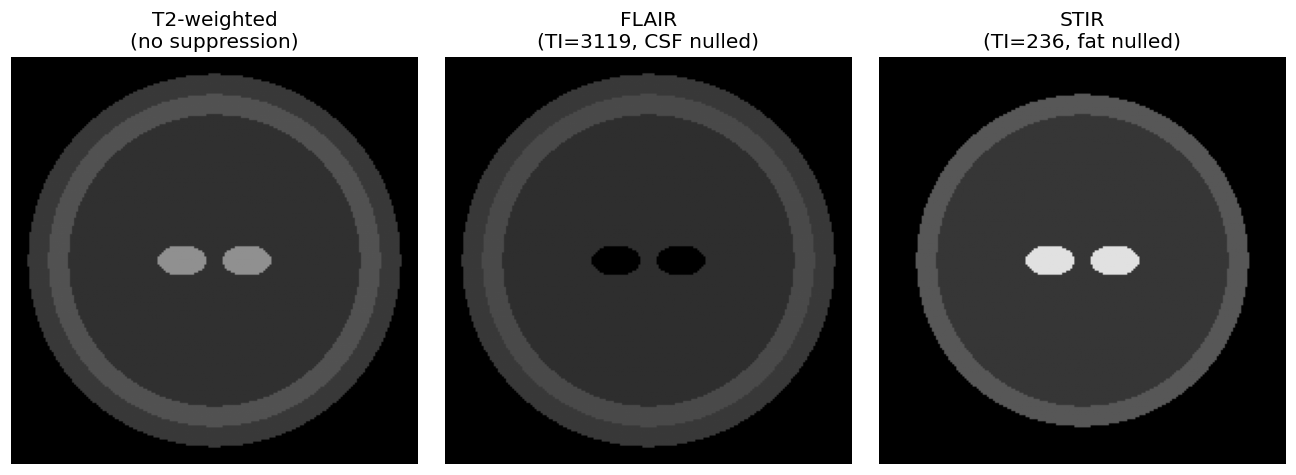

In [10]:
def ir_signal(lab, TI, TE):
    img = np.zeros(lab.shape, float)
    for code_, name in LAB2TISSUE.items():
        p = TISSUES[name]
        s = p["rho"]*abs(1 - 2*np.exp(-TI/p["T1"]))*np.exp(-TE/p["T2"])
        img[lab == code_] = s
    return img

TI_flair = np.log(2)*TISSUES["CSF"]["T1"]
TI_stir  = np.log(2)*TISSUES["Fat"]["T1"]
print(f"FLAIR TI = {TI_flair:.0f} ms   |   STIR TI = {TI_stir:.0f} ms")

panels = [("T2-weighted\n(no suppression)", se_signal(lab, 4000, 90)),
          (f"FLAIR\n(TI={TI_flair:.0f}, CSF nulled)", ir_signal(lab, TI_flair, 90)),
          (f"STIR\n(TI={TI_stir:.0f}, fat nulled)",  ir_signal(lab, TI_stir, 40))]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, (title, img) in zip(axes, panels):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

## 10. $T_1$ and $T_2$ mapping by curve fitting

Mapping measures the *parameter itself*: sample several TE (or TI), then fit the relaxation model per voxel. Here we do it for one noisy voxel.

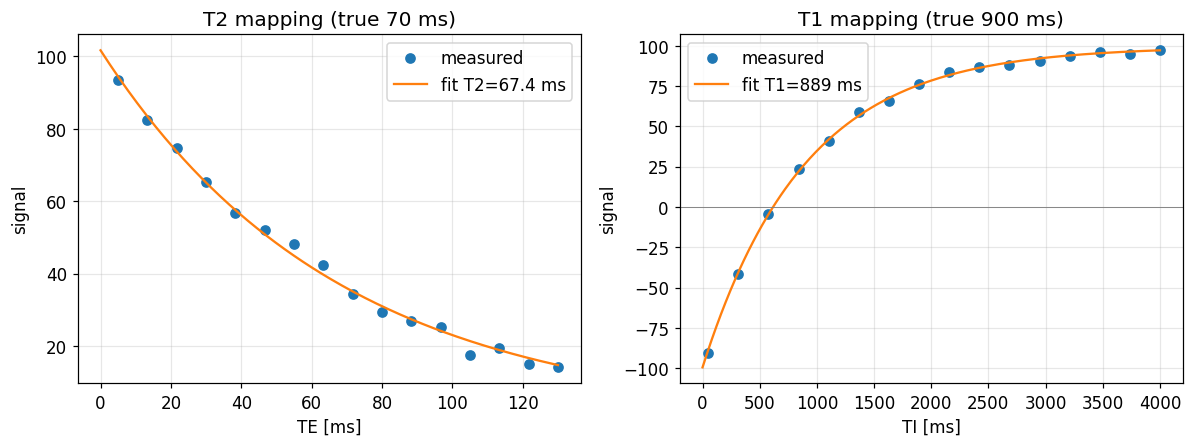

Recovered T2 = 67.4 ms (true 70)
Recovered T1 = 889 ms (true 900)


In [11]:
rng = np.random.default_rng(0)

# ----- T2 mapping: multi-TE -----
T2_true, M0_true = 70.0, 100.0
TEs = np.linspace(5, 130, 16)
S_te = M0_true*np.exp(-TEs/T2_true) + rng.normal(0, 2.0, TEs.size)
f_t2 = lambda te, M0, T2: M0*np.exp(-te/T2)
(p2, _) = curve_fit(f_t2, TEs, S_te, p0=[100, 50])

# ----- T1 mapping: multi-TI -----
T1_true = 900.0
TIs = np.linspace(50, 4000, 16)
S_ti = M0_true*(1 - 2*np.exp(-TIs/T1_true)) + rng.normal(0, 2.0, TIs.size)
f_t1 = lambda ti, M0, T1: M0*(1 - 2*np.exp(-ti/T1))
(p1, _) = curve_fit(f_t1, TIs, S_ti, p0=[100, 500])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(TEs, S_te, "o", label="measured")
ax[0].plot(np.linspace(0,130,200), f_t2(np.linspace(0,130,200), *p2), "-",
           label=f"fit T2={p2[1]:.1f} ms")
ax[0].set_title(f"T2 mapping (true {T2_true:.0f} ms)"); ax[0].set_xlabel("TE [ms]")
ax[0].set_ylabel("signal"); ax[0].legend()

ax[1].plot(TIs, S_ti, "o", label="measured")
ax[1].plot(np.linspace(0,4000,300), f_t1(np.linspace(0,4000,300), *p1), "-",
           label=f"fit T1={p1[1]:.0f} ms")
ax[1].axhline(0, color="gray", lw=.6)
ax[1].set_title(f"T1 mapping (true {T1_true:.0f} ms)"); ax[1].set_xlabel("TI [ms]")
ax[1].set_ylabel("signal"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"Recovered T2 = {p2[1]:.1f} ms (true {T2_true:.0f})")
print(f"Recovered T1 = {p1[1]:.0f} ms (true {T1_true:.0f})")

## 11. Exercise Sheet 12 — worked in code

We use the relaxation times from the **exercise-sheet tables** (1.5 T): CSF $T_1{=}4500,\,T_2{=}2200$; white matter $T_1{=}884,\,T_2{=}72$; gray matter $T_1{=}1124,\,T_2{=}95$ (ms).

In [12]:
EX = {  # exercise-sheet values, 1.5 T (ms)
    "CSF":          dict(T1=4500, T2=2200, color="tab:blue"),
    "Gray matter":  dict(T1=1124, T2=95,   color="tab:gray"),
    "White matter": dict(T1=884,  T2=72,   color="black"),
}

### Exercise 12.1 — $T_1$-weighting

$M_\parallel(t)/M_0 = 1-e^{-t/T_1}$ with $M_\parallel(0)=0$. Evaluate at $t=100$ ms, $1$ s, $10$ s.

M_par(t)/M0 = 1 - exp(-t/T1)

tissue           100 ms       1 s      10 s
CSF               0.022     0.199     0.892
Gray matter       0.085     0.589     1.000
White matter      0.107     0.677     1.000


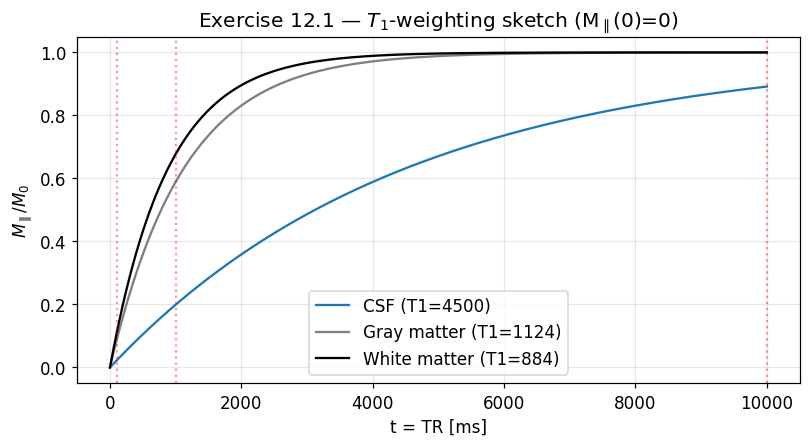

In [13]:
ts = {"100 ms": 100, "1 s": 1000, "10 s": 10000}
print("M_par(t)/M0 = 1 - exp(-t/T1)\n")
print(f"{'tissue':13s}" + "".join(f"{k:>10s}" for k in ts))
for name, p in EX.items():
    vals = [1 - np.exp(-t/p["T1"]) for t in ts.values()]
    print(f"{name:13s}" + "".join(f"{v:>10.3f}" for v in vals))

t = np.linspace(0, 10000, 600)
plt.figure(figsize=(7.5, 4.2))
for name, p in EX.items():
    plt.plot(t, 1-np.exp(-t/p["T1"]), color=p["color"], label=f"{name} (T1={p['T1']})")
for t0, lbl in ts.items():
    plt.axvline(lbl, color="red", ls=":", alpha=.4)
plt.xlabel("t = TR [ms]"); plt.ylabel(r"$M_\parallel/M_0$")
plt.title("Exercise 12.1 — $T_1$-weighting sketch (M$_\\parallel$(0)=0)")
plt.legend(); plt.tight_layout(); plt.show()

**Discussion.** Setting $\mathrm{TR}=t$:

- **$t=100$ ms:** all tissues barely recovered (CSF 0.02, GM 0.08, WM 0.11). The absolute differences are small → **weak** contrast and low signal.
- **$t=1$ s:** large separation (WM 0.68, GM 0.59, CSF 0.20) → **strong** $T_1$-weighting; this is the useful regime.
- **$t=10$ s:** everything ≈1 (fully recovered, $\mathrm{TR}\gg T_1$) → **no** $T_1$ contrast (proton-density-like).

So $T_1$-weighting rises from zero, peaks at TR comparable to the tissue $T_1$ (~hundreds of ms to ~1 s for brain), then vanishes again as TR → ∞.

### Exercise 12.2 — $T_2$-weighting

$M_\perp(t)/M_0 = e^{-t/T_2}$ with $M_\perp(0)=M_0$. Evaluate at $t=5$ ms and $t=50$ ms.

M_perp(t)/M0 = exp(-t/T2)

tissue             5 ms     50 ms
CSF               0.998     0.978
Gray matter       0.949     0.591
White matter      0.933     0.499


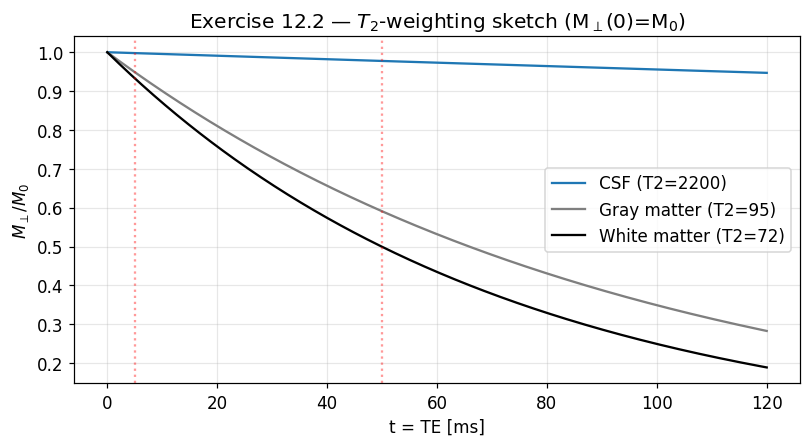

In [14]:
ts = {"5 ms": 5, "50 ms": 50}
print("M_perp(t)/M0 = exp(-t/T2)\n")
print(f"{'tissue':13s}" + "".join(f"{k:>10s}" for k in ts))
for name, p in EX.items():
    vals = [np.exp(-t/p["T2"]) for t in ts.values()]
    print(f"{name:13s}" + "".join(f"{v:>10.3f}" for v in vals))

t = np.linspace(0, 120, 400)
plt.figure(figsize=(7.5, 4.2))
for name, p in EX.items():
    plt.plot(t, np.exp(-t/p["T2"]), color=p["color"], label=f"{name} (T2={p['T2']})")
for lbl in ts.values():
    plt.axvline(lbl, color="red", ls=":", alpha=.4)
plt.xlabel("t = TE [ms]"); plt.ylabel(r"$M_\perp/M_0$")
plt.title("Exercise 12.2 — $T_2$-weighting sketch (M$_\\perp$(0)=M$_0$)")
plt.legend(); plt.tight_layout(); plt.show()

**Discussion.** Setting $\mathrm{TE}=t$:

- **$t=5$ ms:** all near 1 (CSF 0.998, GM 0.95, WM 0.93) → **weak** $T_2$-weighting (≈ proton-density).
- **$t=50$ ms:** clear separation (CSF 0.978, GM 0.59, WM 0.50) → **strong** $T_2$-weighting, CSF bright.

$T_2$-weighting **increases monotonically with TE** (until SNR runs out). And comparing the tables: $T_2$ (tens of ms, CSF excepted) is **far shorter than $T_1$** (hundreds–thousands of ms) — which is exactly why TE $\ll$ TR in practice.

### Exercise 12.4 — Signal loss under FLAIR vs STIR preparation

A tissue with $T_1=1$ s, fully relaxed ($\mathrm{TR}\gg T_1$), gets a 180° inversion. Its signal fraction at the inversion time is $|1-2e^{-\mathrm{TI}/T_1}|$.

- FLAIR nulls CSF: $\mathrm{TI}=\ln2\cdot4500\approx3119$ ms
- STIR nulls fat: $\mathrm{TI}=\ln2\cdot340\approx236$ ms

In [15]:
T1_tissue = 1000.0      # ms
TI_flair = np.log(2)*4500
TI_stir  = np.log(2)*340

def signal_frac(TI, T1):
    return abs(1 - 2*np.exp(-TI/T1))

for label, TI in [("FLAIR", TI_flair), ("STIR", TI_stir)]:
    frac = signal_frac(TI, T1_tissue)
    print(f"{label:6s}  TI={TI:6.0f} ms   signal = {frac:5.3f} M0   "
          f"-> lost {100*(1-frac):4.1f}%")

FLAIR   TI=  3119 ms   signal = 0.912 M0   -> lost  8.8%
STIR    TI=   236 ms   signal = 0.580 M0   -> lost 42.0%


**Result.**

- **FLAIR** (TI ≈ 3119 ms): the tissue has nearly recovered, signal ≈ **0.91 $M_0$** → only **~9%** lost.
- **STIR** (TI ≈ 236 ms): the tissue is still near its zero-crossing, $M_\parallel\approx-0.58\,M_0$, so magnitude signal ≈ **0.58 $M_0$** → **~42%** lost.

STIR's short TI costs this $T_1{=}1$ s tissue much more signal than FLAIR's long TI — the price of suppressing the short-$T_1$ fat is dragging every other tissue down near the null. (Exercise 12.3 is the visual quiz: $T_1$w = CSF dark / fat bright; $T_2$w = CSF bright; $\rho$w = soft grey-white contrast, CSF mid-grey — compare against the §8 phantom.)

## Try it yourself

- Switch `TISSUES` to **3 T** values (CSF unchanged, others longer $T_1$) and re-run §8 — does $T_1$ contrast change?
- In §5/§6, find the TE that maximizes CSF-vs-GM contrast, and the TR that maximizes fat-vs-CSF contrast.
- In §9, sweep TI and watch each tissue cross zero; confirm the null at $\ln2\,T_1$.
- In §10, crank up the noise — at what level does the $T_1$ fit break? Add **magnitude** (`abs`) to the $T_1$ data and refit; what goes wrong, and how would you fix it?
- Re-derive Prof. Laun's "exploding image": flip the sign of the $T_2$ term in `bloch_rhs` and watch $|M_\perp|$ grow without bound.